### **Instalación de librerías**

pip install shap scikit-learn xgboost

In [4]:
import shap
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

### **Entrenamiento del Modelo Random Forest Regresor**

In [ ]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")
print("Predicted value[0]:", model.predict(X_test[:1]))

Model trained successfully.
Predicted value: [0.5095]


### **Calcular los valores SHAP**

In [6]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)

100%|===================| 4118/4128 [05:43<00:00]        

### **Visualización SHAP**

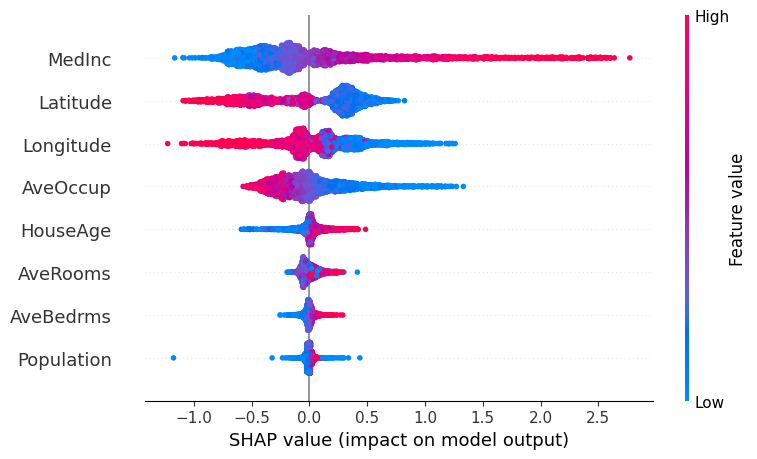

In [7]:
shap.summary_plot(shap_values, X_test)

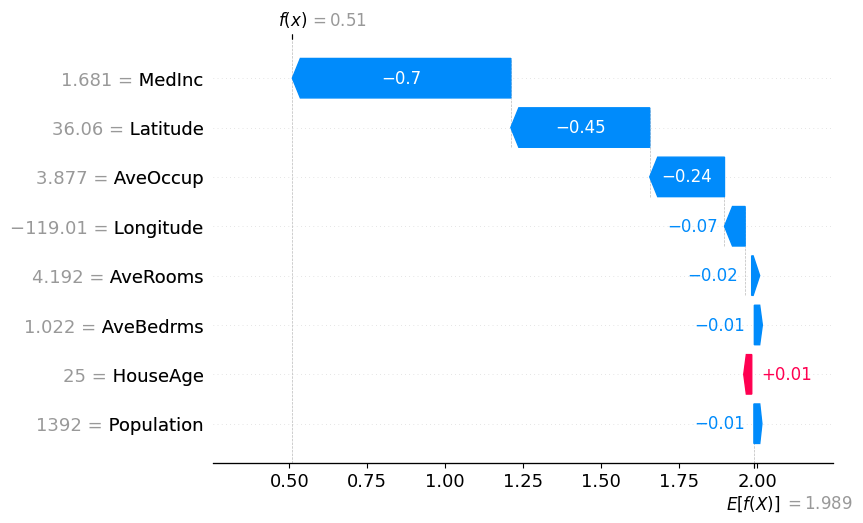

In [8]:
shap.plots.waterfall(shap_values[0])

**NOTA:** El modelo predice el **valor mediano** de las casas en distritos de California (en unidades de $100,000 USD).**

Significado de cada feature:
- MedInc: Ingreso mediano del distrito (en decenas de miles de USD)
- HouseAge: Edad mediana de las casas en el distrito (años)
- AveRooms: Promedio de habitaciones por vivienda
- AveBedrms: Promedio de dormitorios por vivienda
- Population: Población total del distrito
- AveOccup: Promedio de ocupantes por vivienda
- Latitude: Latitud geográfica del distrito
- Longitude: Longitud geográfica del distrito